# Lab 06 - Porównanie modeli klasyfikacyjnych (Wine - zbiór dodatkowy)

Dodatkowa analiza na zbiorze **Wine** z repozytorium UCI. Ćwiczenie wykonałem tym samym schematem co na zbiorze Breast Cancer.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from IPython.display import display


## 1. Wczytanie i opis zbioru danych

Zbiór **Wine** zawiera wyniki analizy chemicznej trzech odmian wina pochodzących z tego samego regionu we Włoszech. Zadaniem jest przypisanie próbki do jednej z trzech klas (odmian). Jest to klasyfikacja **wieloklasowa** (3 klasy), w przeciwieństwie do binarnego Breast Cancer.

In [7]:
from sklearn.datasets import load_wine

data = load_wine()
X = data.data
y = data.target

print(f"Liczba próbek: {X.shape[0]}")
print(f"Liczba cech: {X.shape[1]}")
print(f"Klasy: {data.target_names}")
print(f"Rozkład klas: {dict(zip(data.target_names, np.bincount(y)))}")
print(f"Brakujące wartości: {np.isnan(X).sum()}")

Liczba próbek: 178
Liczba cech: 13
Klasy: ['class_0' 'class_1' 'class_2']
Rozkład klas: {np.str_('class_0'): np.int64(59), np.str_('class_1'): np.int64(71), np.str_('class_2'): np.int64(48)}
Brakujące wartości: 0


## 2. Wizualizacja separowalności klas

Poniżej przedstawiłem dwa wykresy PCA - z i bez standaryzacji.

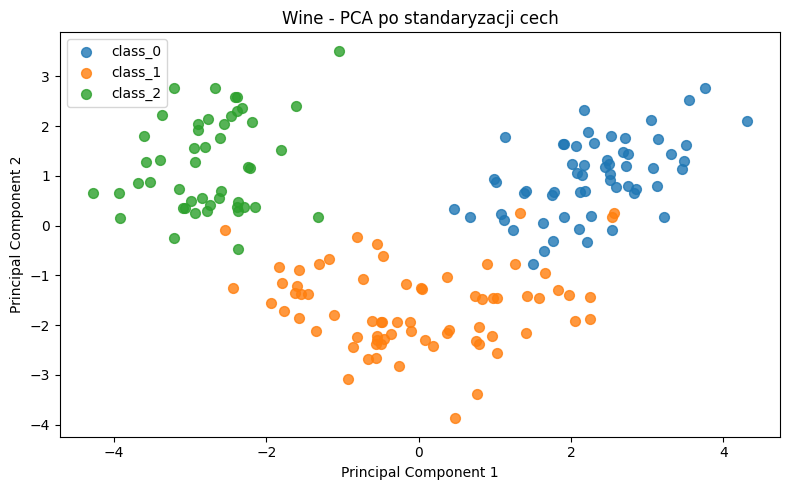

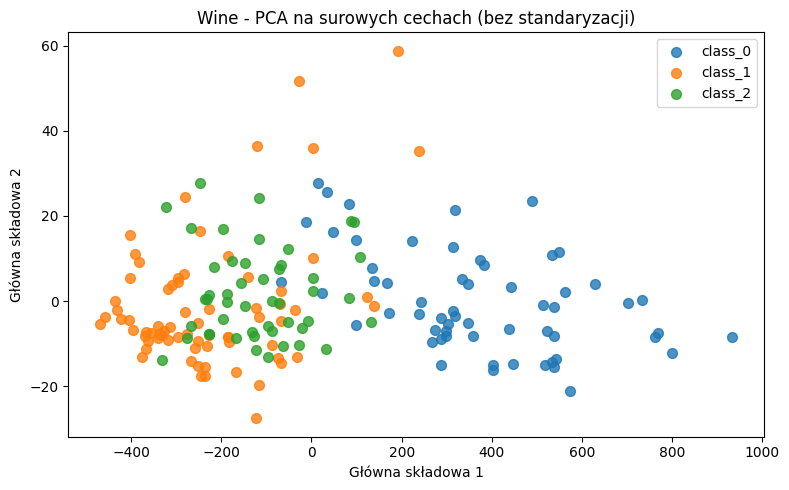

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["tab:blue", "tab:orange", "tab:green"]
for label, name, color in zip(range(3), data.target_names, colors):
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.8, s=50, c=color)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Wine - PCA po standaryzacji cech")
ax.legend()
plt.tight_layout()
plt.show()

pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["tab:blue", "tab:orange", "tab:green"]
for label, name, color in zip(range(3), data.target_names, colors):
    mask = y == label
    ax.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1], label=name, alpha=0.8, s=50, c=color)

ax.set_xlabel("Główna składowa 1")
ax.set_ylabel("Główna składowa 2")
ax.set_title("Wine - PCA na surowych cechach (bez standaryzacji)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Walidacja krzyżowa i porównanie modeli

Mniejszy zbiór (178 próbek, 13 cech) i klasyfikacja 3-klasowa mogą dawać większy rozrzut wyników między foldami niż w Breast Cancer — to dobry przykład wpływu wielkości próby na niepewność estymatora.

Wyniki walidacji krzyżowej


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Średnia accuracy,Odch. stand.
0,Logistic Regression,1.0000,0.9722,1.0000,0.9714,1.0000,0.9887,0.0138
1,Random Forest,1.0000,1.0000,0.9444,0.9714,1.0000,0.9832,0.0223
2,SVM,1.0000,0.9722,0.9722,0.9714,0.9714,0.9775,0.0113
3,KNN,0.9444,0.9167,0.9722,0.9429,0.9714,0.9495,0.0207


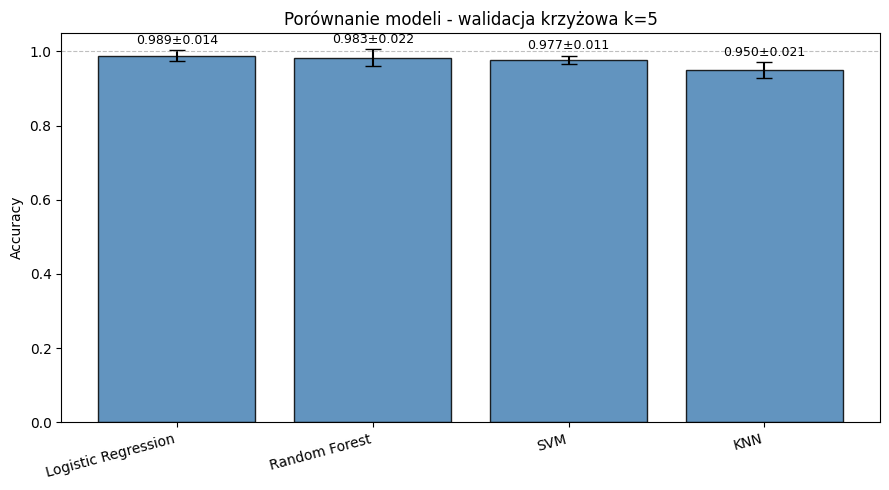

In [10]:
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(random_state=42)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier()),
    ]),
}

results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="accuracy"
    )

    results.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Średnia accuracy": scores.mean(),
        "Odch. stand.": scores.std(),
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Średnia accuracy",
    ascending=False
).reset_index(drop=True)

print("Wyniki walidacji krzyżowej")

display(
    results_df.style
    .format({
        "Fold 1": "{:.4f}",
        "Fold 2": "{:.4f}",
        "Fold 3": "{:.4f}",
        "Fold 4": "{:.4f}",
        "Fold 5": "{:.4f}",
        "Średnia accuracy": "{:.4f}",
        "Odch. stand.": "{:.4f}",
    })
    .background_gradient(
        subset=["Średnia accuracy"],
        cmap="Greens"
    )
    .set_caption(
        f"Porównanie modeli ({K}-fold Cross Validation)"
    )
)

fig, ax = plt.subplots(figsize=(9, 5))

x_pos = np.arange(len(results_df))
means = results_df["Średnia accuracy"].values
stds = results_df["Odch. stand."].values
labels = results_df["Model"].values

bars = ax.bar(
    x_pos,
    means,
    yerr=stds,
    capsize=6,
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title(f"Porównanie modeli - walidacja krzyżowa k={K}")
ax.set_ylim(0, 1.05)

ax.axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.5
)

for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        m + s + 0.01,
        f"{m:.3f}±{s:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


Najlepszym modelem do tych danych okazuje się być Logistic Regression, które osiągnęło średnią dokładność na poziomie 0,9887, miało niskie odchylenie standardowe oraz w trzech foldach miało 100% dokładność.

## 4. Wnioski

#### Rozdzielność zbioru
Zbiór danych jest dobrze rozdzielny.

#### Niepewność estymatora
Na mniejszym zbiorze Wine (178 próbek vs 569 w Breast Cancer) odchylenia są większe - mniejsza ilość próbek jest zapewne powodem większej niepewności estymacji.

#### Model
Modelem, który osiąga najlepsze wyniki dla zbioru Wine jest Logistic Regression, jest on dobrym kompromisem pomiędzy dokładnością a stabilnością. <br>
Random Forest również ma bardzo wysoką dokładność, ale za to dwa razy większe odchylenie standardowe - jest on mniej stabilny, dlatego dla tych danych wybrałbym LR.

#### Porównanie z Breast Cancer

| Aspekt | Breast Cancer | Wine |
|--------|---------------|------|
| Liczba próbek | 569 | 178 |
| Liczba klas | 2 | 3 |
| Separowalność | wysoka | wysoka |
| Typowa niepewność CV | niska (std ~0,01) | wyższa (std ~0,01–0,02) |